# Determining electric conductivity $\sigma$ and magnetic field $B$

### Imports

In [9]:

from pathlib import Path
import numpy as np
import warnings


import matplotlib.pyplot as plt


from ppvm_py.utils import load_object

from ppvm_py.plotting import plot_heatmap
from ppvm_py.plotting import generate_2d_video

from ppvm_py.data_processing.patt_fld8v import print_xyz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.sigma_and_b_estimation import calc_conductivity_with_z

from ppvm_py.feature_generation.sdc import compute_symmetric_difference_coefficients_with_index_to_coord_map

### General Args

In [2]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 1000

if Ha == 300:
    patt_fld8v_folder_path = Path("../../../../data/4pi_re1000_ha300.360_ch28.p1/patt_fld8v/")
elif Ha == 1000:
    patt_fld8v_folder_path = Path("../../../../data/4pi_re1000_ha1000.384.pi/patt_fld8v/")

fld_path = patt_fld8v_folder_path / Path("pkl/patt_fld8v.pkl")

# Estimates from evaluations
sigma = -1  # According to the results here.
B_z = -1  # According to the results here.

animation_folder = Path("animations")

truncate_data = True
truncate_at_snapshot = 10  # Including indices 0 to (truncate_at_snapshot - 1)

### Load Data

In [3]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    if truncate_data:
        fld_data['timeseries'] = fld_data['timeseries'][:truncate_at_snapshot]
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_xyz_slice_example_from_parsed_data(fld_data)

Object successfully loaded from C:\Users\hydro\Documents\PhD\nuclear_fusion_cooling\data\4pi_re1000_ha1000.384.pi\patt_fld8v\pkl\patt_fld8v.pkl
The 3D data looks as follows:
N (number of snapshots) = 10
n_x (grid depth) = 577, n_y (grid height) = 97, n_z (grid width) = 97, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 x, first 2 y, first 2 z) with coordinates:
  (x=0.00, y=-1.00, z=-1.00): [ 0.          0.          0.          0.          0.          0.
  0.00070366 -0.1506608 ]
  (x=0.00, y=-1.00, z=-0.99): [ 0.          0.          0.          0.          0.         -0.01773967
  0.00071547 -0.1506508 ]
  (x=0.00, y=-0.99, z=-1.00): [ 0.         0.         0.         0.         0.3698478  0.
  0.0007184 -0.1515782]
  (x=0.00, y=-0.99, z=-0.99): [ 0.          0.          0.          0.          0.4032355  -0.00119388
  0.00074057 -0.1516712 ]
  (x=0.02, y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.0000

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

## Ohm's Law in z-coord

### Estimate $\frac{\partial{\phi}}{\partial{z}}$

In [4]:
part_phi_z = compute_symmetric_difference_coefficients_with_index_to_coord_map(
    fld_data['timeseries'][..., fld_data['labels'].index('F')],
    direction_axis=3,
    index_to_coord_map=fld_data['index_to_coord_map'],
)

non_zero_data_indices = (
    slice(None),
    slice(None),
    slice(1, -1),
    slice(1, -1),
)  # Exclude first and last y and z index (sdc can not be calculated there).
part_phi_z = part_phi_z[non_zero_data_indices]

### Find 0 Entries

##### $\frac{\partial{\phi}}{\partial{z}}$

In [5]:
# plot_heatmap(
#     np.all(
#         part_phi_z[:, 400, ...] == 0,
#         axis=0,
#         ),
#     title='part_phi_z',
#     x_label='y',
#     y_label='z',
#     )

# i_start = 200
# generate_2d_video(
#     data = np.all(
#         part_phi_z[:, i_start:, ...] == 0,
#         axis=0,
#         ),
#     output_file_path="animations/part_phi_z_zeros.gif",
#     fps=10,
#     xlabel="Y Axis",
#     ylabel="Z Axis",
#     title_pattern="X Index: " + f"{i_start} + " + " {}" if i_start != 0 else "X Index: {}",
# )

##### $j_z$

In [6]:
j_z = fld_data['timeseries'][
    :,
    :,
    :,
    :,
    fld_data['labels'].index('jz'),
]
j_z = j_z[non_zero_data_indices]

# plot_heatmap(
#     np.all(
#         j_z[:, 400, ...] == 0,
#         axis=0,
#         ),
#     title='part_phi_z',
#     x_label='y',
#     y_label='z',
#     )

# i_start = 0
# generate_2d_video(
#     data = np.all(
#         j_z == 0,
#         axis=0,
#         ),
#     output_file_path="animations/j_z_zeros.gif",
#     fps=10,
#     xlabel="Y Axis",
#     ylabel="Z Axis",
#     title_pattern="X Index: " + f"{i_start} + " + " {}" if i_start != 0 else "X Index: {}",
# )

### Calculate Sigma

In [7]:
part_phi_z_non_zero_mask = (part_phi_z != 0)

sigma_est = np.divide(
    j_z,
    part_phi_z,
    out=np.full_like(part_phi_z, np.nan),
    where=part_phi_z_non_zero_mask,
)

##### Mean

In [ ]:
# Some slices along axis 0 are nan, therefore a warning is always printed.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    mean = np.nanmean(
        sigma_est,
        axis=0,
    )
    mean_mean = np.nanmean(
        mean,
    )

print(f"mean(mean(sigma_est)) = {mean_mean}")

# plot_heatmap(
#     mean,
#     title='mean',
#     x_label='y',
#     y_label='z',
#     index_to_space_dict=fld_data['index_to_coord_map'],
#     round_decimals=2,
#     max_ticks=7,
#     )

mean(mean(sigma_est)) = -0.9182130604227403


##### 3 Std Dev

In [ ]:
# std = np.std(
#         sigma_est,
#         axis=0,
#         out=np.full(sigma_est.shape[1:], np.nan),
#         where=part_phi_z_non_zero_mask,
#         )
# std3 = np.full_like(std, np.nan)
# std3[~np.isnan(std)] = 3 * std[~np.isnan(std)]
# median = np.median(
#         sigma_est,
#         axis=0,
#         )

# mean_std3 = np.mean(
#     std3,
#     where=~np.isnan(std3),
# )

# print(f"mean(3 * std(sigma_est)) = {mean_std3}")

# plot_heatmap(
#     3*std,
#     title='3 * std',
#     x_label='y',
#     y_label='z',
#     index_to_space_dict=fld_data['index_to_coord_map'],
#     round_decimals=2,
#     max_ticks=7,
#     )

##### Median

In [ ]:
# median = np.median(
#         sigma_est,
#         axis=0,
#         )

# median_median = np.mean(
#     median,
#     )

# print(f"median(median(sigma_est)) = {median_median}")

# plot_heatmap(
#     median,
#     title='median',
#     x_label='y',
#     y_label='z',
#     index_to_space_dict=fld_data['index_to_coord_map'],
#     round_decimals=2,
#     max_ticks=7,
#     )

## Ohm's Law in x-coord

### Find 0 Entries

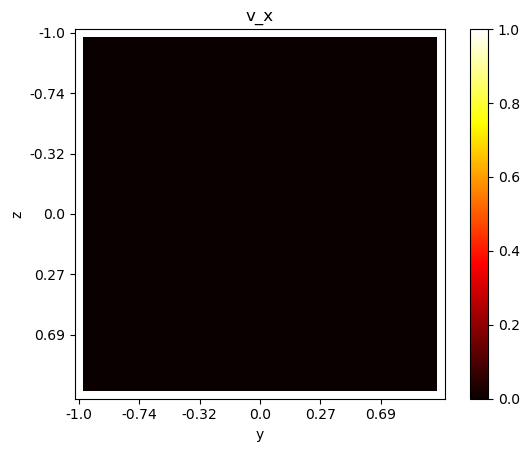

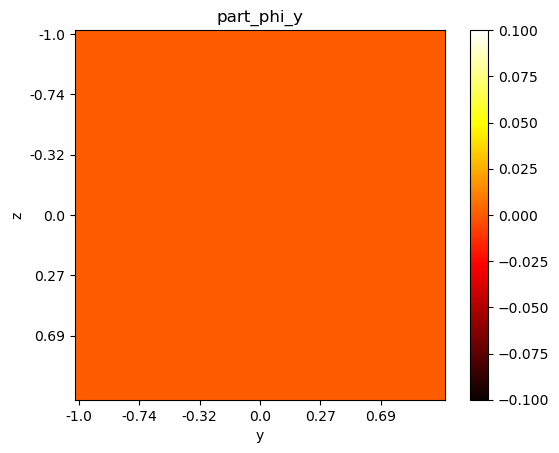

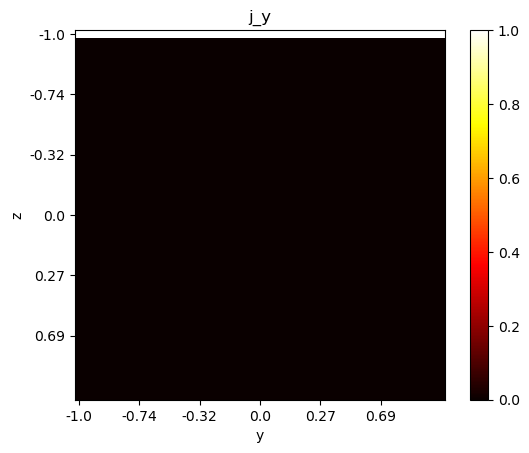

In [ ]:
# v_x
v_x = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('vx'),
    ]
plot_heatmap(
    np.all(
        v_x == 0,
        axis=0,
        ),
    title='v_x',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
v_x = v_x[:, 1:-1, 1:-1]


# part_phi_y
part_phi_y = gradF_data['timeseries'][
    :,
    :,
    :,
    gradF_data['labels'].index('dfdy'),
    ]
plot_heatmap(
    np.all(
        part_phi_y == 0,
        axis=0,
        ),
    title='part_phi_y',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
part_phi_y = part_phi_y[:, 1:-1, 1:-1]


# j_y
j_y = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('jy'),
    ]
plot_heatmap(
    np.all(
        j_y == 0,
        axis=0,
        ),
    title='j_y',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
j_y = j_y[:, 1:-1, 1:-1]

### Estimate $B_z$

In [ ]:
B_z_est = np.divide(
    part_phi_y - j_y / sigma,
    v_x,
    )

##### Mean

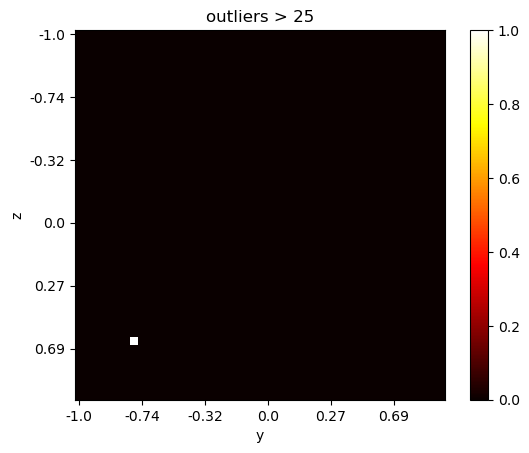

mean(mean(B_z_est) | mean(B_z_est) < 25) = -1.0005376557322523


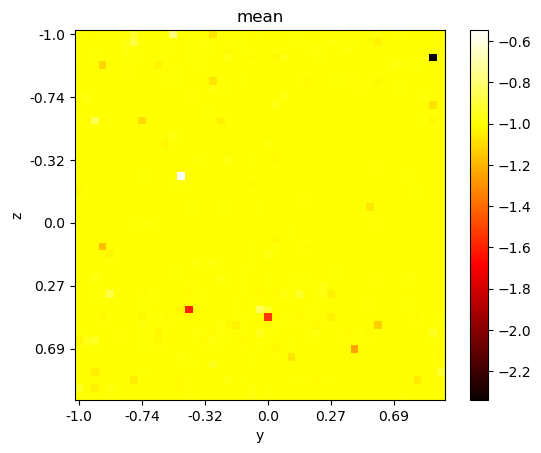

In [ ]:
mean = np.mean(
    B_z_est,
    axis=0,
    )

plot_heatmap(
    mean > 25,
    title='outliers > 25',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
print(f"mean(mean(B_z_est) | mean(B_z_est) < 25) = {np.mean(mean[mean < 25])}")


# Adjust outlier for better plot.
mean_wo_outlier = mean.copy()
mean_wo_outlier[mean_wo_outlier > 25] = np.median(mean_wo_outlier)

plot_heatmap(
    mean_wo_outlier,
    title='mean',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

##### 3-Std-Dev

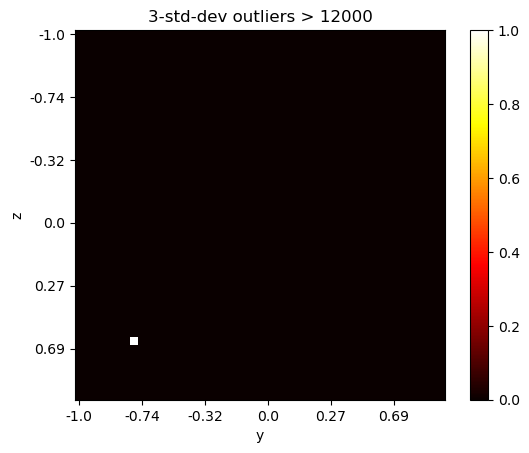

mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = 2.098521502962123


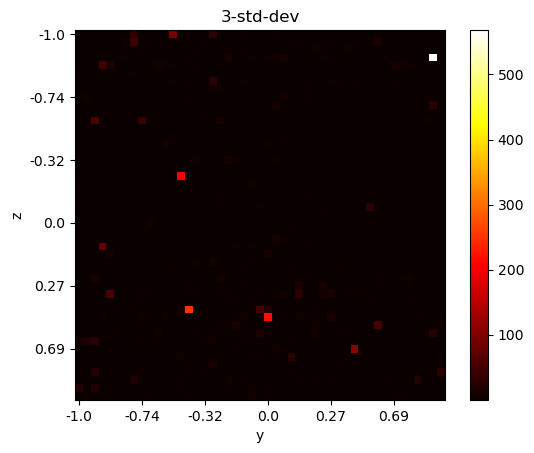

In [ ]:
std = np.std(
    B_z_est,
    axis=0,
    )
std_3 = 3 * std

plot_heatmap(
    std_3 > 12000,
    title='3-std-dev outliers > 12000',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
print(f"mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = {np.mean(std_3[std_3 < 12000])}")

# Adjust outlier for better plot.
std_3_wo_outlier = std_3.copy()
std_3_wo_outlier[std_3_wo_outlier > 12000] = np.median(std_3_wo_outlier)

plot_heatmap(
    std_3_wo_outlier,
    title='3-std-dev',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

##### Median

median(median(B_z_est)) = -0.9998806212571416


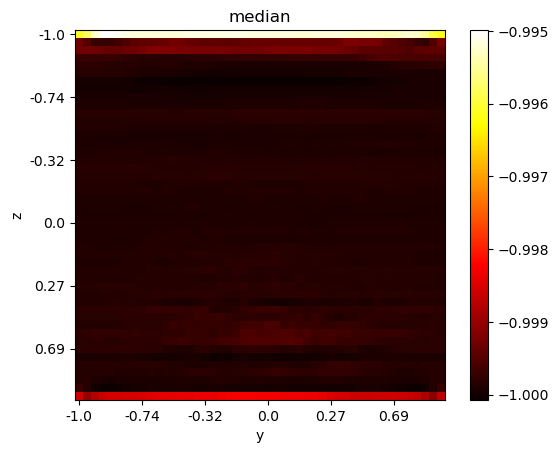

In [ ]:
median = np.median(
    B_z_est,
    axis=0,
    )

print(f"median(median(B_z_est)) = {np.median(median)}")
plot_heatmap(
    median,
    title='median',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

### Calculate Sigma

##### Epsilon on 0 Divisors

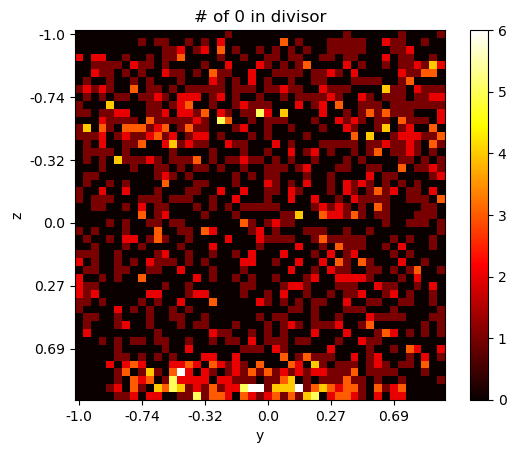

In [ ]:
divisor = part_phi_y - v_x * B_z
# plot_heatmap(
#     np.any(
#         divisor == 0,
#         axis=0,
#         ),
#     title='divisor',
#     x_label='y',
#     y_label='z',
#     index_to_space_dict=fld_data['index_to_coord_map'],
#     round_decimals=2,
#     max_ticks=7,
#     )
plot_heatmap(
    np.sum(divisor == 0, axis=0),
    title='# of 0 in divisor',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
epsilon = 10e-100
divisor_plus_eps = divisor.copy()
divisor_plus_eps[divisor == 0] += epsilon

##### Main

mean(mean(sigma_est_ts)) = -0.8039007829499176
mean(3 * std(sigma_est_ts)) = 135.18886701714877
median(median(sigma_est_ts)) = -0.8368650308810219


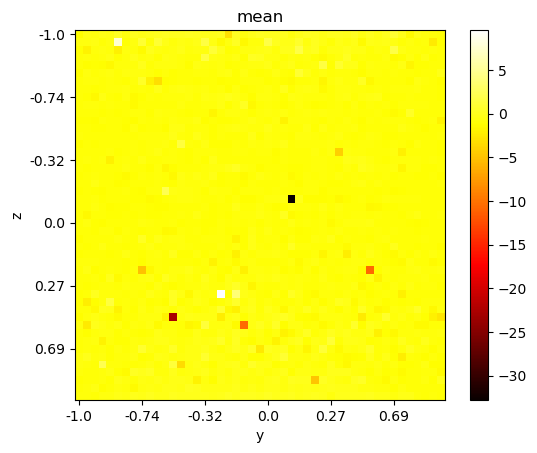

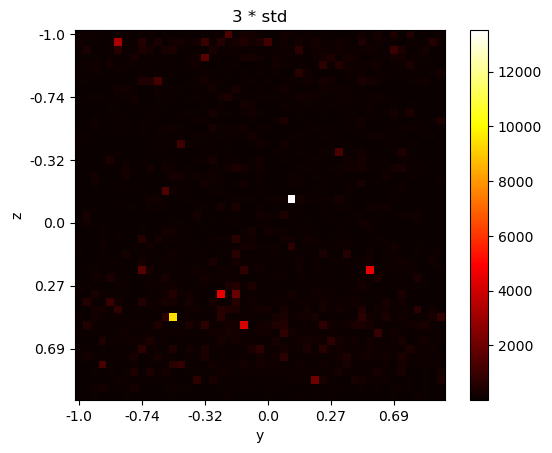

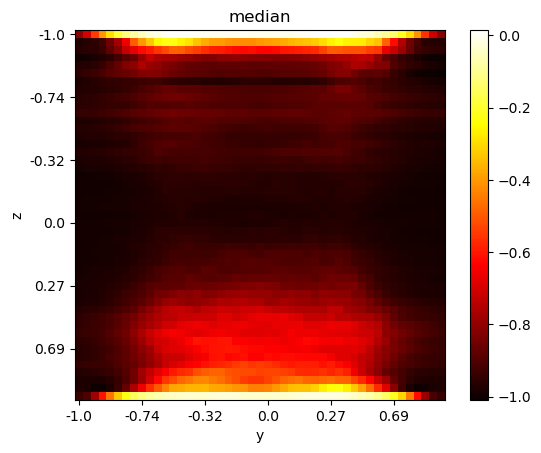

In [ ]:
sigma_est = np.divide(
    j_y,
    divisor_plus_eps,
    )

mean = np.mean(
        sigma_est,
        axis=0,
        where=(divisor != 0),
        )
std = np.std(
        sigma_est,
        axis=0,
        where=(divisor != 0),
        )
std3 = 3 * std
median = np.median(
        sigma_est,
        axis=0,
        )

mean_mean = np.mean(
    mean,
    )
mean_std3 = np.mean(
    std3,
    )
median_median = np.mean(
    median,
    )

# # Exclude 0 entries
# mean_mean = np.mean(
#     mean[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )
# mean_std3 = np.mean(
#     std3[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )
# median_median = np.mean(
#     median[np.all(
#         divisor != 0,
#         axis=0,
#         )],
#     )

print(f"mean(mean(sigma_est)) = {mean_mean}")
print(f"mean(3 * std(sigma_est)) = {mean_std3}")
print(f"median(median(sigma_est)) = {median_median}")

plot_heatmap(
    mean,
    title='mean',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    std3,
    title='3 * std',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )
plot_heatmap(
    median,
    title='median',
    x_label='y',
    y_label='z',
    index_to_space_dict=fld_data['index_to_coord_map'],
    round_decimals=2,
    max_ticks=7,
    )

### Why no uniform $\sigma$?

Rationale: Look at the following $\min{j_y}$:

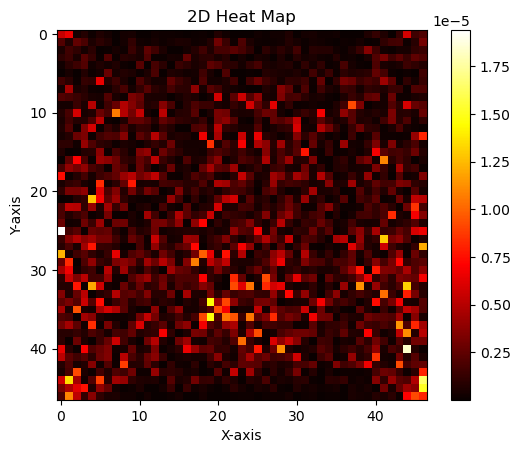

In [ ]:
plot_heatmap(np.min(np.abs(j_y), axis=0))

Sigma is expected to be $-1$, therefore, denominator and numerator should be more or less equal in abs terms. But for really small values, which we see we have, numerical problems are expected, and they do not fit. Particularly, we have some 0 within them as we have seen before. In the top and bottom region we have especially small values, so there, the sigma estimates are particularly off.